## **Verify Convergence. Initial k = 1e-8**

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy

# Problem parameters
kappa = 1e-8       # thermal diffusivity [m^2/s]. We will learn this parameter.
depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
z0 = 0.017
z1 = 0.363
N = 100



# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# Now each data point will be calculated using the spatial average of the sensor.

# Space out the depths in N equal slices.
x_depths = jnp.linspace(z0, z1, N).reshape(-1, 1)

t_data = jnp.array(ltst_mole).reshape(-1, 1)
u_data = jnp.array(temp_mole).reshape(-1, 1)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_depths = normalize_x(x_depths)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: idctionary containging the network list of dictionaries and log_kappa
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = {}

    network = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        network.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    params['network'] = network
    params['log_kappa'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)


    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]

    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    kappa_eff = normalize_kappa(jnp.exp(params['log_kappa']))  # Ensure positivity

    return du_dt / kappa_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
params = init_network_params(layer_sizes, key)

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={100000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, tx_all, u_data):

    def loss_fn(params):

        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel()) # (10000,) not (10000, 1)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss

        # One forward pass, reshape, average
        preds = network(params, tx_all)           # (M*100, 1)
        preds = preds.reshape(-1, N)             # (M, 100)
        avg_preds = jnp.mean(preds, axis=1, keepdims=True)  # (M, 1)
        data_loss = jnp.mean((avg_preds - u_data)**2)

        return  bc_loss * 100 + physics_loss + data_loss * 200, (bc_loss, physics_loss, data_loss)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 300000
save_every = 1000
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()


# Build (M*100, 2) tensor in one go
t_repeated = jnp.repeat(t_data, N, axis=0)      # each tᵢ repeated 100 times
x_tiled = jnp.tile(x_depths, (len(t_data), 1))  # depths tiled M times
tx_all = jnp.concatenate([t_repeated, x_tiled], axis=1)


# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
kappa_history = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        tx_all, u_data
    )

    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])
    kappa_history.append(float(jnp.exp(params['log_kappa'])))


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  BC Loss: {individual_loss[0]:.6f}, Physics Loss: {individual_loss[1]:.6f}, Data Loss: {individual_loss[2]:.6f}")
        print(f"  Current kappa: {jnp.exp(params['log_kappa']):.2e} m^2/s")


import pickle

checkpoint = {
    # Learned parameters
    'params': jax.device_get(params),
    'opt_state': jax.device_get(opt_state),

    # Loss histories
    'losses': [float(l) for l in losses],
    'losses_bc': [float(l) for l in losses_bc],
    'losses_phys': [float(l) for l in losses_phys],
    'losses_data': [float(l) for l in losses_data],
    'kappa_history': kappa_history,

    # Snapshots for animation
    'snapshots': [jax.device_get(s) for s in snapshots],
    'snapshot_iterations': snapshot_iterations,

    # Training config (so you remember what produced this)
    'num_iterations': num_iterations,
    'layer_sizes': layer_sizes,
    'learning_rate': learning_rate,
    'final_kappa': float(jnp.exp(params['log_kappa'])),
}

with open('checkpoints_spatial_average/1e-8_run01.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print(f"Checkpoint saved. Final kappa: {jnp.exp(params['log_kappa']):.2e}")

/usr/local/lib/python3.12/dist-packages/openpyxl/reader/drawings.py:67: UserWarning: wmf image format is not supported so the image is being dropped
  warn(msg)


Iteration 1000/300000, Loss: 6.536188
  BC Loss: 0.057184, Physics Loss: 0.685280, Data Loss: 0.000663
  Current kappa: 1.01e-08 m^2/s
Iteration 2000/300000, Loss: 6.012614
  BC Loss: 0.056219, Physics Loss: 0.290522, Data Loss: 0.000501
  Current kappa: 1.01e-08 m^2/s
Iteration 3000/300000, Loss: 5.797115
  BC Loss: 0.055527, Physics Loss: 0.164330, Data Loss: 0.000400
  Current kappa: 1.01e-08 m^2/s
Iteration 4000/300000, Loss: 5.676333
  BC Loss: 0.055104, Physics Loss: 0.093771, Data Loss: 0.000361
  Current kappa: 1.01e-08 m^2/s
Iteration 5000/300000, Loss: 5.607837
  BC Loss: 0.054717, Physics Loss: 0.066849, Data Loss: 0.000346
  Current kappa: 1.01e-08 m^2/s
Iteration 6000/300000, Loss: 5.538206
  BC Loss: 0.054180, Physics Loss: 0.051547, Data Loss: 0.000343
  Current kappa: 1.02e-08 m^2/s
Iteration 7000/300000, Loss: 5.451951
  BC Loss: 0.053335, Physics Loss: 0.051684, Data Loss: 0.000334
  Current kappa: 1.02e-08 m^2/s
Iteration 8000/300000, Loss: 5.297493
  BC Loss: 0.0514

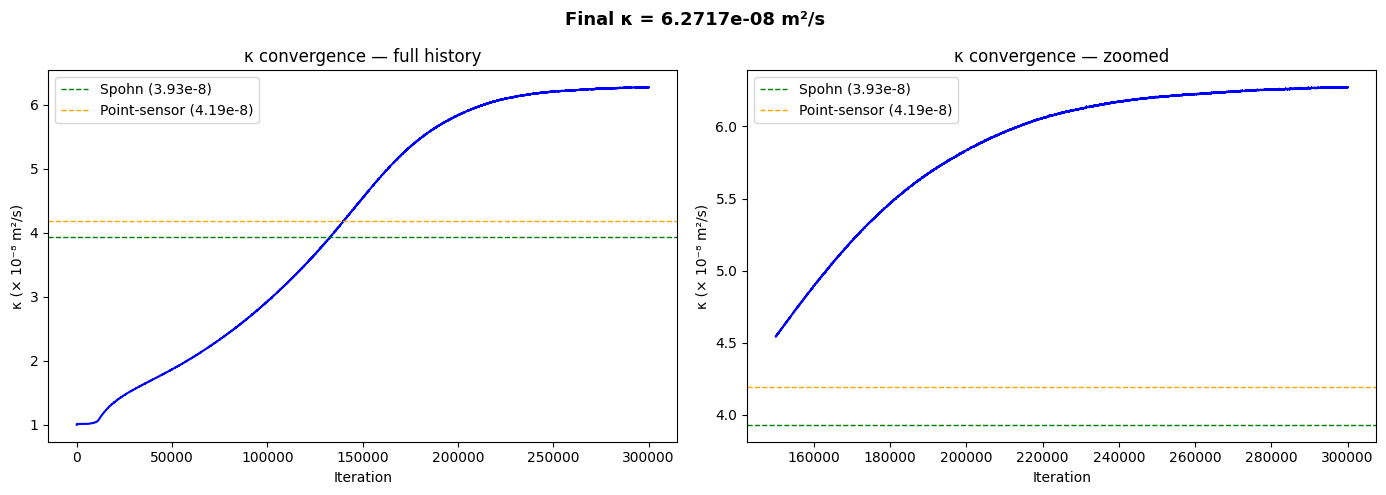

Final κ:          6.2717e-08 m²/s
Spohn reference:  3.93e-8 m²/s  (diff: +59.6%)


In [ ]:
# ── κ convergence plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = jnp.arange(1, len(kappa_history) + 1)

# (a) Full history
axes[0].plot(iters, jnp.array(kappa_history) * 1e8, 'b-', lw=1.5)
axes[0].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[0].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[0].set_title('κ convergence — full history')
axes[0].legend()

# (b) Zoomed on last 50% to see plateau
half = len(kappa_history) // 2
axes[1].plot(iters[half:], jnp.array(kappa_history)[half:] * 1e8, 'b-', lw=1.5)
axes[1].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[1].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[1].set_title('κ convergence — zoomed')
axes[1].legend()

final_kappa = kappa_history[-1]
plt.suptitle(f'Final κ = {final_kappa:.4e} m²/s', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kappa_convergence_1e-8_run2.png', dpi=150)
plt.show()

print(f"Final κ:          {final_kappa:.4e} m²/s")
print(f"Spohn reference:  3.93e-8 m²/s  (diff: {(final_kappa - 3.93e-8)/3.93e-8 * 100:+.1f}%)")


**Iterations until Convergence**

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy

# Problem parameters
depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
z0 = 0.017
z1 = 0.363
N = 100



# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

with open('checkpoints_spatial_average/1e-8_run01.pkl', 'rb') as f:
    checkpoint = pickle.load(f)


kappa = checkpoint['final_kappa']

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# Now each data point will be calculated using the spatial average of the sensor.

# Space out the depths in N equal slices.
x_depths = jnp.linspace(z0, z1, N).reshape(-1, 1)

t_data = jnp.array(ltst_mole).reshape(-1, 1)
u_data = jnp.array(temp_mole).reshape(-1, 1)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_depths = normalize_x(x_depths)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: idctionary containging the network list of dictionaries and log_kappa
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = {}

    network = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        network.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    params['network'] = network
    params['log_kappa'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)


    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]

    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    kappa_eff = normalize_kappa(jnp.exp(params['log_kappa']))  # Ensure positivity

    return du_dt / kappa_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={50000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(checkpoint['params'])


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, tx_all, u_data):

    def loss_fn(params):

        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel()) # (10000,) not (10000, 1)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss

        # One forward pass, reshape, average
        preds = network(params, tx_all)           # (M*100, 1)
        preds = preds.reshape(-1, N)             # (M, 100)
        avg_preds = jnp.mean(preds, axis=1, keepdims=True)  # (M, 1)
        data_loss = jnp.mean((avg_preds - u_data)**2)

        return  bc_loss * 100 + physics_loss + data_loss * 200, (bc_loss, physics_loss, data_loss)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 50000
save_every = 1000
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()


# Build (M*100, 2) tensor in one go
t_repeated = jnp.repeat(t_data, N, axis=0)      # each tᵢ repeated 100 times
x_tiled = jnp.tile(x_depths, (len(t_data), 1))  # depths tiled M times
tx_all = jnp.concatenate([t_repeated, x_tiled], axis=1)


# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
kappa_history = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        tx_all, u_data
    )

    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])
    kappa_history.append(float(jnp.exp(params['log_kappa'])))


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  BC Loss: {individual_loss[0]:.6f}, Physics Loss: {individual_loss[1]:.6f}, Data Loss: {individual_loss[2]:.6f}")
        print(f"  Current kappa: {jnp.exp(params['log_kappa']):.2e} m^2/s")


import pickle

checkpoint = {
    # Learned parameters
    'params': jax.device_get(params),
    'opt_state': jax.device_get(opt_state),

    # Loss histories
    'losses': [float(l) for l in losses],
    'losses_bc': [float(l) for l in losses_bc],
    'losses_phys': [float(l) for l in losses_phys],
    'losses_data': [float(l) for l in losses_data],
    'kappa_history': kappa_history,

    # Snapshots for animation
    'snapshots': [jax.device_get(s) for s in snapshots],
    'snapshot_iterations': snapshot_iterations,

    # Training config (so you remember what produced this)
    'num_iterations': num_iterations,
    'layer_sizes': layer_sizes,
    'learning_rate': learning_rate,
    'final_kappa': float(jnp.exp(params['log_kappa'])),
}

with open('checkpoints_spatial_average/1e-8_run02.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print(f"Checkpoint saved. Final kappa: {jnp.exp(params['log_kappa']):.2e}")

Iteration 1000/50000, Loss: 0.001140
  BC Loss: 0.000002, Physics Loss: 0.000248, Data Loss: 0.000004
  Current kappa: 6.26e-08 m^2/s
Iteration 2000/50000, Loss: 0.001335
  BC Loss: 0.000002, Physics Loss: 0.000407, Data Loss: 0.000004
  Current kappa: 6.26e-08 m^2/s
Iteration 3000/50000, Loss: 0.002836
  BC Loss: 0.000002, Physics Loss: 0.001729, Data Loss: 0.000004
  Current kappa: 6.26e-08 m^2/s
Iteration 4000/50000, Loss: 0.001390
  BC Loss: 0.000002, Physics Loss: 0.000531, Data Loss: 0.000003
  Current kappa: 6.27e-08 m^2/s
Iteration 5000/50000, Loss: 0.001121
  BC Loss: 0.000002, Physics Loss: 0.000222, Data Loss: 0.000004
  Current kappa: 6.27e-08 m^2/s
Iteration 6000/50000, Loss: 0.002497
  BC Loss: 0.000004, Physics Loss: 0.001161, Data Loss: 0.000005
  Current kappa: 6.27e-08 m^2/s
Iteration 7000/50000, Loss: 0.002240
  BC Loss: 0.000005, Physics Loss: 0.000490, Data Loss: 0.000006
  Current kappa: 6.27e-08 m^2/s
Iteration 8000/50000, Loss: 0.003535
  BC Loss: 0.000002, Phys

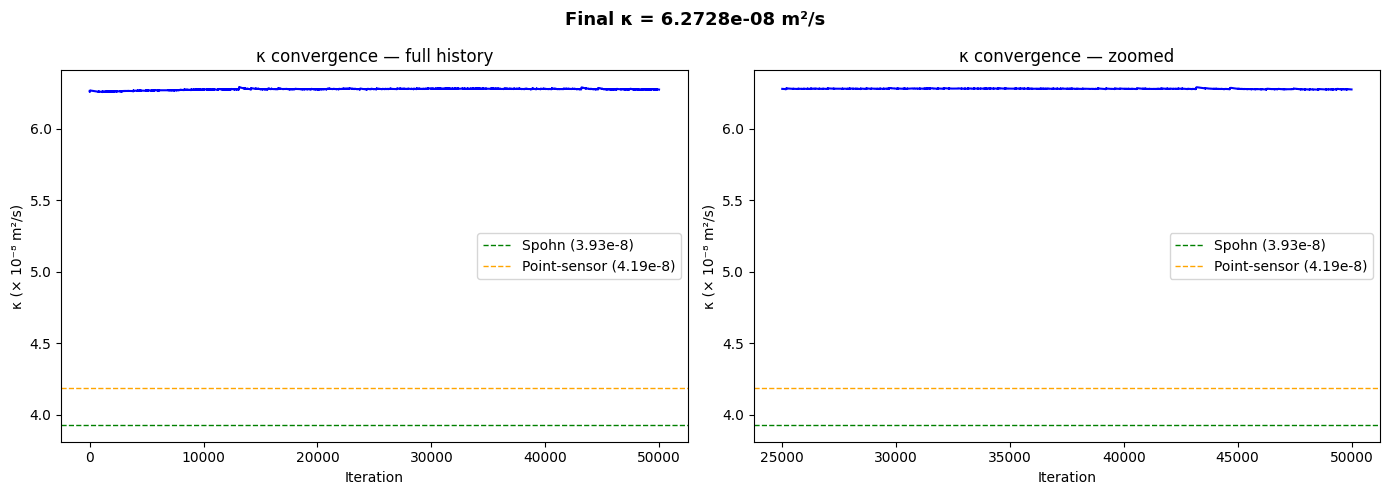

Final κ:          6.2728e-08 m²/s
Spohn reference:  3.93e-8 m²/s  (diff: +59.6%)


In [ ]:
# ── κ convergence plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = jnp.arange(1, len(kappa_history) + 1)

# (a) Full history
axes[0].plot(iters, jnp.array(kappa_history) * 1e8, 'b-', lw=1.5)
axes[0].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[0].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[0].set_title('κ convergence — full history')
axes[0].legend()

# (b) Zoomed on last 50% to see plateau
half = len(kappa_history) // 2
axes[1].plot(iters[half:], jnp.array(kappa_history)[half:] * 1e8, 'b-', lw=1.5)
axes[1].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[1].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[1].set_title('κ convergence — zoomed')
axes[1].legend()

final_kappa = kappa_history[-1]
plt.suptitle(f'Final κ = {final_kappa:.4e} m²/s', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kappa_convergence_1e-8_run2.png', dpi=150)
plt.show()

print(f"Final κ:          {final_kappa:.4e} m²/s")
print(f"Spohn reference:  3.93e-8 m²/s  (diff: {(final_kappa - 3.93e-8)/3.93e-8 * 100:+.1f}%)")

## **Verify Convergence. Initial k = 3.93e-8**

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy

# Problem parameters
kappa = 3.93e-8       # thermal diffusivity [m^2/s]. We will learn this parameter.
depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
z0 = 0.017
z1 = 0.363
N = 100



# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# Now each data point will be calculated using the spatial average of the sensor.

# Space out the depths in N equal slices.
x_depths = jnp.linspace(z0, z1, N).reshape(-1, 1)

t_data = jnp.array(ltst_mole).reshape(-1, 1)
u_data = jnp.array(temp_mole).reshape(-1, 1)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_depths = normalize_x(x_depths)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: idctionary containging the network list of dictionaries and log_kappa
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = {}

    network = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        network.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    params['network'] = network
    params['log_kappa'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)


    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]

    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    kappa_eff = normalize_kappa(jnp.exp(params['log_kappa']))  # Ensure positivity

    return du_dt / kappa_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
params = init_network_params(layer_sizes, key)

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={60000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, tx_all, u_data):

    def loss_fn(params):

        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel()) # (10000,) not (10000, 1)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss

        # One forward pass, reshape, average
        preds = network(params, tx_all)           # (M*100, 1)
        preds = preds.reshape(-1, N)             # (M, 100)
        avg_preds = jnp.mean(preds, axis=1, keepdims=True)  # (M, 1)
        data_loss = jnp.mean((avg_preds - u_data)**2)

        return  bc_loss * 100 + physics_loss + data_loss * 200, (bc_loss, physics_loss, data_loss)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 200000
save_every = 1000
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()


# Build (M*100, 2) tensor in one go
t_repeated = jnp.repeat(t_data, N, axis=0)      # each tᵢ repeated 100 times
x_tiled = jnp.tile(x_depths, (len(t_data), 1))  # depths tiled M times
tx_all = jnp.concatenate([t_repeated, x_tiled], axis=1)


# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
kappa_history = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        tx_all, u_data
    )

    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])
    kappa_history.append(float(jnp.exp(params['log_kappa'])))


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  BC Loss: {individual_loss[0]:.6f}, Physics Loss: {individual_loss[1]:.6f}, Data Loss: {individual_loss[2]:.6f}")
        print(f"  Current kappa: {jnp.exp(params['log_kappa']):.2e} m^2/s")


import pickle

checkpoint = {
    # Learned parameters
    'params': jax.device_get(params),
    'opt_state': jax.device_get(opt_state),

    'kappa_history': kappa_history,

    # Snapshots for animation
    'snapshots': [jax.device_get(s) for s in snapshots],
    'snapshot_iterations': snapshot_iterations,

    # Training config (so you remember what produced this)
    'num_iterations': num_iterations,
    'layer_sizes': layer_sizes,
    'learning_rate': learning_rate,
    'final_kappa': float(jnp.exp(params['log_kappa'])),
}

with open('checkpoints_spatial_average/3.93e-8_run01.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print(f"Checkpoint saved. Final kappa: {jnp.exp(params['log_kappa']):.2e}")

/usr/local/lib/python3.12/dist-packages/openpyxl/reader/drawings.py:67: UserWarning: wmf image format is not supported so the image is being dropped
  warn(msg)


Iteration 1000/200000, Loss: 5.088172
  BC Loss: 0.048404, Physics Loss: 0.192130, Data Loss: 0.000278
  Current kappa: 3.99e-08 m^2/s
Iteration 2000/200000, Loss: 4.267725
  BC Loss: 0.040395, Physics Loss: 0.186979, Data Loss: 0.000206
  Current kappa: 4.00e-08 m^2/s
Iteration 3000/200000, Loss: 3.219977
  BC Loss: 0.029744, Physics Loss: 0.216113, Data Loss: 0.000147
  Current kappa: 4.01e-08 m^2/s
Iteration 4000/200000, Loss: 1.423383
  BC Loss: 0.013141, Physics Loss: 0.092892, Data Loss: 0.000082
  Current kappa: 4.03e-08 m^2/s
Iteration 5000/200000, Loss: 0.609500
  BC Loss: 0.005531, Physics Loss: 0.047896, Data Loss: 0.000043
  Current kappa: 4.05e-08 m^2/s
Iteration 6000/200000, Loss: 0.258968
  BC Loss: 0.002025, Physics Loss: 0.050394, Data Loss: 0.000030
  Current kappa: 4.07e-08 m^2/s
Iteration 7000/200000, Loss: 0.233744
  BC Loss: 0.001122, Physics Loss: 0.113531, Data Loss: 0.000040
  Current kappa: 4.10e-08 m^2/s
Iteration 8000/200000, Loss: 0.120708
  BC Loss: 0.0007

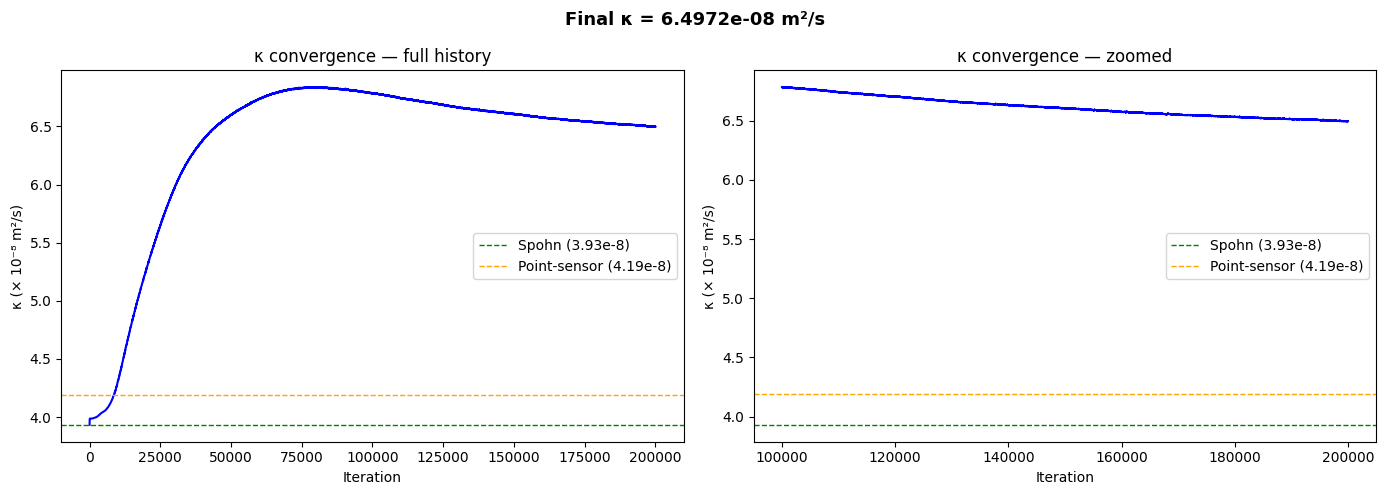

Final κ:          6.4972e-08 m²/s
Spohn reference:  3.93e-8 m²/s  (diff: +65.3%)


In [ ]:
# ── κ convergence plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = jnp.arange(1, len(kappa_history) + 1)

# (a) Full history
axes[0].plot(iters, jnp.array(kappa_history) * 1e8, 'b-', lw=1.5)
axes[0].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[0].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[0].set_title('κ convergence — full history')
axes[0].legend()

# (b) Zoomed on last 50% to see plateau
half = len(kappa_history) // 2
axes[1].plot(iters[half:], jnp.array(kappa_history)[half:] * 1e8, 'b-', lw=1.5)
axes[1].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[1].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[1].set_title('κ convergence — zoomed')
axes[1].legend()

final_kappa = kappa_history[-1]
plt.suptitle(f'Final κ = {final_kappa:.4e} m²/s', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kappa_convergence_3.93e-8_run01.png', dpi=150)
plt.show()

print(f"Final κ:          {final_kappa:.4e} m²/s")
print(f"Spohn reference:  3.93e-8 m²/s  (diff: {(final_kappa - 3.93e-8)/3.93e-8 * 100:+.1f}%)")

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy

# Problem parameters
depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
z0 = 0.017
z1 = 0.363
N = 100



# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

with open('checkpoints_spatial_average/3.93e-8_run01.pkl', 'rb') as f:
    checkpoint = pickle.load(f)


kappa = checkpoint['final_kappa']

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# Now each data point will be calculated using the spatial average of the sensor.

# Space out the depths in N equal slices.
x_depths = jnp.linspace(z0, z1, N).reshape(-1, 1)

t_data = jnp.array(ltst_mole).reshape(-1, 1)
u_data = jnp.array(temp_mole).reshape(-1, 1)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_depths = normalize_x(x_depths)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: idctionary containging the network list of dictionaries and log_kappa
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = {}

    network = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        network.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    params['network'] = network
    params['log_kappa'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)


    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]

    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    kappa_eff = normalize_kappa(jnp.exp(params['log_kappa']))  # Ensure positivity

    return du_dt / kappa_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={50000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(checkpoint['params'])


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, tx_all, u_data):

    def loss_fn(params):

        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel()) # (10000,) not (10000, 1)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss

        # One forward pass, reshape, average
        preds = network(params, tx_all)           # (M*100, 1)
        preds = preds.reshape(-1, N)             # (M, 100)
        avg_preds = jnp.mean(preds, axis=1, keepdims=True)  # (M, 1)
        data_loss = jnp.mean((avg_preds - u_data)**2)

        return  bc_loss * 100 + physics_loss + data_loss * 200, (bc_loss, physics_loss, data_loss)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 200000
save_every = 1000
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()


# Build (M*100, 2) tensor in one go
t_repeated = jnp.repeat(t_data, N, axis=0)      # each tᵢ repeated 100 times
x_tiled = jnp.tile(x_depths, (len(t_data), 1))  # depths tiled M times
tx_all = jnp.concatenate([t_repeated, x_tiled], axis=1)


# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
kappa_history = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        tx_all, u_data
    )

    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])
    kappa_history.append(float(jnp.exp(params['log_kappa'])))


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  BC Loss: {individual_loss[0]:.6f}, Physics Loss: {individual_loss[1]:.6f}, Data Loss: {individual_loss[2]:.6f}")
        print(f"  Current kappa: {jnp.exp(params['log_kappa']):.2e} m^2/s")


import pickle

checkpoint = {
    # Learned parameters
    'params': jax.device_get(params),
    'opt_state': jax.device_get(opt_state),

    # Loss histories
    'losses': [float(l) for l in losses],
    'losses_bc': [float(l) for l in losses_bc],
    'losses_phys': [float(l) for l in losses_phys],
    'losses_data': [float(l) for l in losses_data],
    'kappa_history': kappa_history,

    # Snapshots for animation
    'snapshots': [jax.device_get(s) for s in snapshots],
    'snapshot_iterations': snapshot_iterations,

    # Training config (so you remember what produced this)
    'num_iterations': num_iterations,
    'layer_sizes': layer_sizes,
    'learning_rate': learning_rate,
    'final_kappa': float(jnp.exp(params['log_kappa'])),
}

with open('checkpoints_spatial_average/3.93e-8_run02.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print(f"Checkpoint saved. Final kappa: {jnp.exp(params['log_kappa']):.2e}")

Iteration 1000/200000, Loss: 0.001564
  BC Loss: 0.000002, Physics Loss: 0.000527, Data Loss: 0.000004
  Current kappa: 6.50e-08 m^2/s
Iteration 2000/200000, Loss: 0.008525
  BC Loss: 0.000022, Physics Loss: 0.001281, Data Loss: 0.000025
  Current kappa: 6.49e-08 m^2/s
Iteration 3000/200000, Loss: 0.006369
  BC Loss: 0.000003, Physics Loss: 0.005322, Data Loss: 0.000004
  Current kappa: 6.49e-08 m^2/s
Iteration 4000/200000, Loss: 0.002551
  BC Loss: 0.000002, Physics Loss: 0.001512, Data Loss: 0.000004
  Current kappa: 6.49e-08 m^2/s
Iteration 5000/200000, Loss: 0.003620
  BC Loss: 0.000002, Physics Loss: 0.002590, Data Loss: 0.000004
  Current kappa: 6.49e-08 m^2/s
Iteration 6000/200000, Loss: 0.005640
  BC Loss: 0.000003, Physics Loss: 0.004478, Data Loss: 0.000004
  Current kappa: 6.48e-08 m^2/s
Iteration 7000/200000, Loss: 0.027395
  BC Loss: 0.000019, Physics Loss: 0.021973, Data Loss: 0.000018
  Current kappa: 6.48e-08 m^2/s
Iteration 8000/200000, Loss: 0.003768
  BC Loss: 0.0000

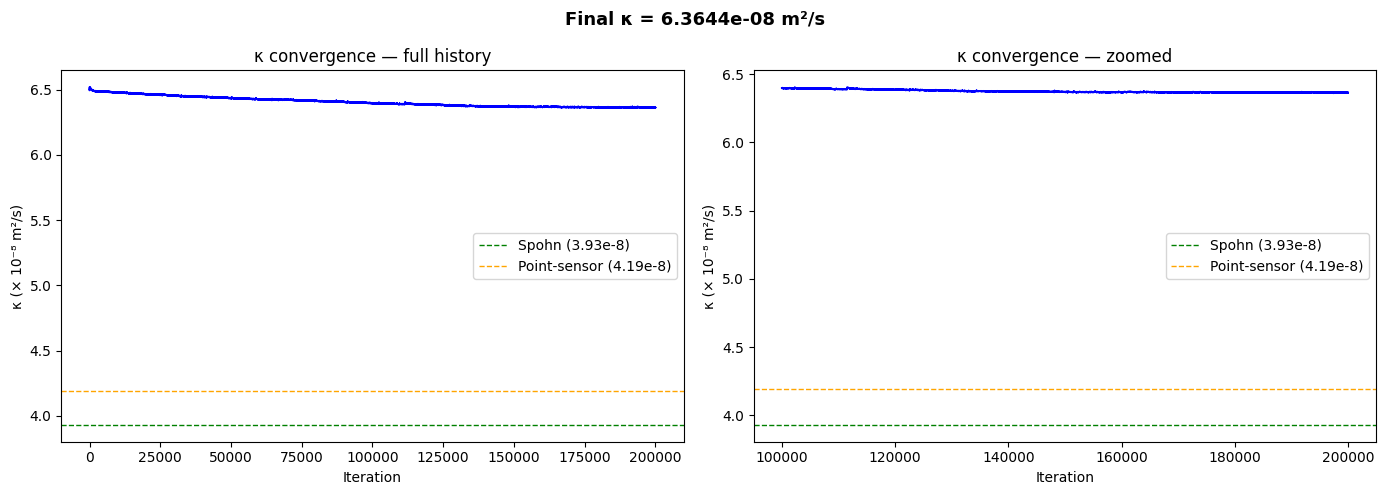

Final κ:          6.3644e-08 m²/s
Spohn reference:  3.93e-8 m²/s  (diff: +61.9%)


In [ ]:
# ── κ convergence plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = jnp.arange(1, len(kappa_history) + 1)

# (a) Full history
axes[0].plot(iters, jnp.array(kappa_history) * 1e8, 'b-', lw=1.5)
axes[0].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[0].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[0].set_title('κ convergence — full history')
axes[0].legend()

# (b) Zoomed on last 50% to see plateau
half = len(kappa_history) // 2
axes[1].plot(iters[half:], jnp.array(kappa_history)[half:] * 1e8, 'b-', lw=1.5)
axes[1].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[1].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[1].set_title('κ convergence — zoomed')
axes[1].legend()

final_kappa = kappa_history[-1]
plt.suptitle(f'Final κ = {final_kappa:.4e} m²/s', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kappa_convergence_3.93e-8_run2.png', dpi=150)
plt.show()

print(f"Final κ:          {final_kappa:.4e} m²/s")
print(f"Spohn reference:  3.93e-8 m²/s  (diff: {(final_kappa - 3.93e-8)/3.93e-8 * 100:+.1f}%)")

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy
import pickle

# Problem parameters
depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
z0 = 0.017
z1 = 0.363
N = 100



# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

with open('checkpoints_spatial_average/3.93e-8_run02.pkl', 'rb') as f:
    checkpoint = pickle.load(f)


kappa = checkpoint['final_kappa']

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# Now each data point will be calculated using the spatial average of the sensor.

# Space out the depths in N equal slices.
x_depths = jnp.linspace(z0, z1, N).reshape(-1, 1)

t_data = jnp.array(ltst_mole).reshape(-1, 1)
u_data = jnp.array(temp_mole).reshape(-1, 1)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_depths = normalize_x(x_depths)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: idctionary containging the network list of dictionaries and log_kappa
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = {}

    network = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        network.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    params['network'] = network
    params['log_kappa'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)


    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]

    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    kappa_eff = normalize_kappa(jnp.exp(params['log_kappa']))  # Ensure positivity

    return du_dt / kappa_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
params = checkpoint['params']

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={50000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, tx_all, u_data):

    def loss_fn(params):

        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel()) # (10000,) not (10000, 1)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss

        # One forward pass, reshape, average
        preds = network(params, tx_all)           # (M*100, 1)
        preds = preds.reshape(-1, N)             # (M, 100)
        avg_preds = jnp.mean(preds, axis=1, keepdims=True)  # (M, 1)
        data_loss = jnp.mean((avg_preds - u_data)**2)

        return  bc_loss * 100 + physics_loss + data_loss * 200, (bc_loss, physics_loss, data_loss)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 500000
save_every = 1000
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()


# Build (M*100, 2) tensor in one go
t_repeated = jnp.repeat(t_data, N, axis=0)      # each tᵢ repeated 100 times
x_tiled = jnp.tile(x_depths, (len(t_data), 1))  # depths tiled M times
tx_all = jnp.concatenate([t_repeated, x_tiled], axis=1)


# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
kappa_history = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        tx_all, u_data
    )

    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])
    kappa_history.append(float(jnp.exp(params['log_kappa'])))


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  BC Loss: {individual_loss[0]:.6f}, Physics Loss: {individual_loss[1]:.6f}, Data Loss: {individual_loss[2]:.6f}")
        print(f"  Current kappa: {jnp.exp(params['log_kappa']):.2e} m^2/s")



checkpoint = {
    # Learned parameters
    'params': jax.device_get(params),
    'opt_state': jax.device_get(opt_state),

    # Loss histories
    'losses': [float(l) for l in losses],
    'losses_bc': [float(l) for l in losses_bc],
    'losses_phys': [float(l) for l in losses_phys],
    'losses_data': [float(l) for l in losses_data],
    'kappa_history': kappa_history,

    # Snapshots for animation
    'snapshots': [jax.device_get(s) for s in snapshots],
    'snapshot_iterations': snapshot_iterations,

    # Training config (so you remember what produced this)
    'num_iterations': num_iterations,
    'layer_sizes': layer_sizes,
    'learning_rate': learning_rate,
    'final_kappa': float(jnp.exp(params['log_kappa'])),
}

with open('checkpoints_spatial_average/3.93e-8_run03.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print(f"Checkpoint saved. Final kappa: {jnp.exp(params['log_kappa']):.2e}")

Iteration 1000/500000, Loss: 0.001294
  BC Loss: 0.000002, Physics Loss: 0.000418, Data Loss: 0.000004
  Current kappa: 6.36e-08 m^2/s
Iteration 2000/500000, Loss: 0.001829
  BC Loss: 0.000002, Physics Loss: 0.000891, Data Loss: 0.000004
  Current kappa: 6.36e-08 m^2/s
Iteration 3000/500000, Loss: 0.003545
  BC Loss: 0.000003, Physics Loss: 0.002500, Data Loss: 0.000004
  Current kappa: 6.36e-08 m^2/s
Iteration 4000/500000, Loss: 0.008270
  BC Loss: 0.000017, Physics Loss: 0.002921, Data Loss: 0.000018
  Current kappa: 6.36e-08 m^2/s
Iteration 5000/500000, Loss: 0.007351
  BC Loss: 0.000002, Physics Loss: 0.006227, Data Loss: 0.000004
  Current kappa: 6.36e-08 m^2/s
Iteration 6000/500000, Loss: 0.007728
  BC Loss: 0.000003, Physics Loss: 0.006358, Data Loss: 0.000005
  Current kappa: 6.36e-08 m^2/s
Iteration 7000/500000, Loss: 0.003623
  BC Loss: 0.000003, Physics Loss: 0.002512, Data Loss: 0.000004
  Current kappa: 6.36e-08 m^2/s
Iteration 8000/500000, Loss: 0.003905
  BC Loss: 0.0000

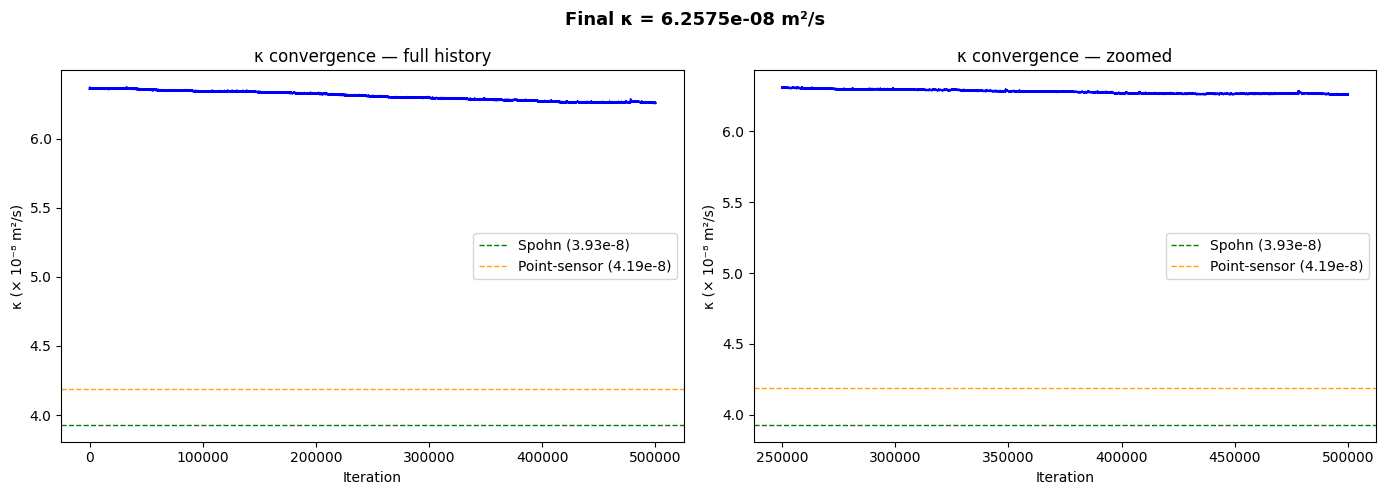

Final κ:          6.2575e-08 m²/s
Spohn reference:  3.93e-8 m²/s  (diff: +59.2%)


In [ ]:
# ── κ convergence plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = jnp.arange(1, len(kappa_history) + 1)

# (a) Full history
axes[0].plot(iters, jnp.array(kappa_history) * 1e8, 'b-', lw=1.5)
axes[0].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[0].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[0].set_title('κ convergence — full history')
axes[0].legend()

# (b) Zoomed on last 50% to see plateau
half = len(kappa_history) // 2
axes[1].plot(iters[half:], jnp.array(kappa_history)[half:] * 1e8, 'b-', lw=1.5)
axes[1].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[1].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[1].set_title('κ convergence — zoomed')
axes[1].legend()

final_kappa = kappa_history[-1]
plt.suptitle(f'Final κ = {final_kappa:.4e} m²/s', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kappa_convergence_3.93e-8_run3.png', dpi=150)
plt.show()

print(f"Final κ:          {final_kappa:.4e} m²/s")
print(f"Spohn reference:  3.93e-8 m²/s  (diff: {(final_kappa - 3.93e-8)/3.93e-8 * 100:+.1f}%)")

## **Verify Convergence. Initial k = 1e-7**

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy

import pickle

# Problem parameters
kappa = 1e-7       # thermal diffusivity [m^2/s]. We will learn this parameter.
depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
z0 = 0.017
z1 = 0.363
N = 100



# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# Now each data point will be calculated using the spatial average of the sensor.

# Space out the depths in N equal slices.
x_depths = jnp.linspace(z0, z1, N).reshape(-1, 1)

t_data = jnp.array(ltst_mole).reshape(-1, 1)
u_data = jnp.array(temp_mole).reshape(-1, 1)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_depths = normalize_x(x_depths)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: idctionary containging the network list of dictionaries and log_kappa
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = {}

    network = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        network.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    params['network'] = network
    params['log_kappa'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)


    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]

    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    kappa_eff = normalize_kappa(jnp.exp(params['log_kappa']))  # Ensure positivity

    return du_dt / kappa_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
params = init_network_params(layer_sizes, key)

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={60000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, tx_all, u_data):

    def loss_fn(params):

        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel()) # (10000,) not (10000, 1)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss

        # One forward pass, reshape, average
        preds = network(params, tx_all)           # (M*100, 1)
        preds = preds.reshape(-1, N)             # (M, 100)
        avg_preds = jnp.mean(preds, axis=1, keepdims=True)  # (M, 1)
        data_loss = jnp.mean((avg_preds - u_data)**2)

        return  bc_loss * 100 + physics_loss + data_loss * 200, (bc_loss, physics_loss, data_loss)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 300000
save_every = 1000
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()


# Build (M*100, 2) tensor in one go
t_repeated = jnp.repeat(t_data, N, axis=0)      # each tᵢ repeated 100 times
x_tiled = jnp.tile(x_depths, (len(t_data), 1))  # depths tiled M times
tx_all = jnp.concatenate([t_repeated, x_tiled], axis=1)


# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
kappa_history = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        tx_all, u_data
    )

    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])
    kappa_history.append(float(jnp.exp(params['log_kappa'])))


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  BC Loss: {individual_loss[0]:.6f}, Physics Loss: {individual_loss[1]:.6f}, Data Loss: {individual_loss[2]:.6f}")
        print(f"  Current kappa: {jnp.exp(params['log_kappa']):.2e} m^2/s")



checkpoint = {
    # Learned parameters
    'params': jax.device_get(params),
    'opt_state': jax.device_get(opt_state),

    'kappa_history': kappa_history,

    # Snapshots for animation
    'snapshots': [jax.device_get(s) for s in snapshots],
    'snapshot_iterations': snapshot_iterations,

    # Training config (so you remember what produced this)
    'num_iterations': num_iterations,
    'layer_sizes': layer_sizes,
    'learning_rate': learning_rate,
    'final_kappa': float(jnp.exp(params['log_kappa'])),
}

with open('checkpoints_spatial_average/1e-7_run01.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print(f"Checkpoint saved. Final kappa: {jnp.exp(params['log_kappa']):.2e}")

/usr/local/lib/python3.12/dist-packages/openpyxl/reader/drawings.py:67: UserWarning: wmf image format is not supported so the image is being dropped
  warn(msg)


Iteration 1000/300000, Loss: 2.568665
  BC Loss: 0.023557, Physics Loss: 0.187913, Data Loss: 0.000125
  Current kappa: 1.02e-07 m^2/s
Iteration 2000/300000, Loss: 0.928532
  BC Loss: 0.008526, Physics Loss: 0.058311, Data Loss: 0.000088
  Current kappa: 1.02e-07 m^2/s
Iteration 3000/300000, Loss: 0.257390
  BC Loss: 0.002073, Physics Loss: 0.036913, Data Loss: 0.000066
  Current kappa: 1.03e-07 m^2/s
Iteration 4000/300000, Loss: 0.117449
  BC Loss: 0.000741, Physics Loss: 0.027319, Data Loss: 0.000080
  Current kappa: 1.03e-07 m^2/s
Iteration 5000/300000, Loss: 0.076709
  BC Loss: 0.000484, Physics Loss: 0.009743, Data Loss: 0.000093
  Current kappa: 1.03e-07 m^2/s
Iteration 6000/300000, Loss: 0.090972
  BC Loss: 0.000407, Physics Loss: 0.038198, Data Loss: 0.000061
  Current kappa: 1.03e-07 m^2/s
Iteration 7000/300000, Loss: 0.052496
  BC Loss: 0.000329, Physics Loss: 0.003825, Data Loss: 0.000079
  Current kappa: 1.03e-07 m^2/s
Iteration 8000/300000, Loss: 0.059162
  BC Loss: 0.0002

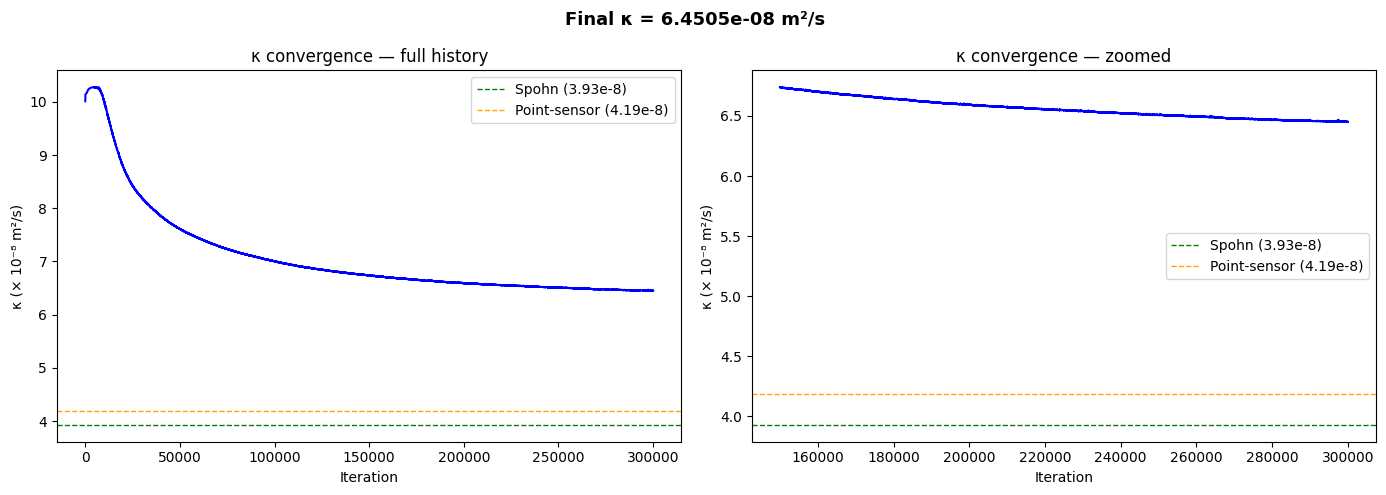

Final κ:          6.4505e-08 m²/s
Spohn reference:  3.93e-8 m²/s  (diff: +64.1%)


In [ ]:
# ── κ convergence plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = jnp.arange(1, len(kappa_history) + 1)

# (a) Full history
axes[0].plot(iters, jnp.array(kappa_history) * 1e8, 'b-', lw=1.5)
axes[0].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[0].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[0].set_title('κ convergence — full history')
axes[0].legend()

# (b) Zoomed on last 50% to see plateau
half = len(kappa_history) // 2
axes[1].plot(iters[half:], jnp.array(kappa_history)[half:] * 1e8, 'b-', lw=1.5)
axes[1].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[1].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[1].set_title('κ convergence — zoomed')
axes[1].legend()

final_kappa = kappa_history[-1]
plt.suptitle(f'Final κ = {final_kappa:.4e} m²/s', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kappa_convergence_1e-7_run01.png', dpi=150)
plt.show()

print(f"Final κ:          {final_kappa:.4e} m²/s")
print(f"Spohn reference:  3.93e-8 m²/s  (diff: {(final_kappa - 3.93e-8)/3.93e-8 * 100:+.1f}%)")

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy
import pickle

# Problem parameters
depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
z0 = 0.017
z1 = 0.363
N = 100



# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

with open('checkpoints_spatial_average/1e-7_run01.pkl', 'rb') as f:
    checkpoint = pickle.load(f)


kappa = checkpoint['final_kappa']

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# Now each data point will be calculated using the spatial average of the sensor.

# Space out the depths in N equal slices.
x_depths = jnp.linspace(z0, z1, N).reshape(-1, 1)

t_data = jnp.array(ltst_mole).reshape(-1, 1)
u_data = jnp.array(temp_mole).reshape(-1, 1)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_depths = normalize_x(x_depths)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: idctionary containging the network list of dictionaries and log_kappa
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = {}

    network = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        network.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    params['network'] = network
    params['log_kappa'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)


    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]

    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    kappa_eff = normalize_kappa(jnp.exp(params['log_kappa']))  # Ensure positivity

    return du_dt / kappa_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
params = checkpoint['params']

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={50000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, tx_all, u_data):

    def loss_fn(params):

        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel()) # (10000,) not (10000, 1)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss

        # One forward pass, reshape, average
        preds = network(params, tx_all)           # (M*100, 1)
        preds = preds.reshape(-1, N)             # (M, 100)
        avg_preds = jnp.mean(preds, axis=1, keepdims=True)  # (M, 1)
        data_loss = jnp.mean((avg_preds - u_data)**2)

        return  bc_loss * 100 + physics_loss + data_loss * 200, (bc_loss, physics_loss, data_loss)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 300000
save_every = 1000
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()


# Build (M*100, 2) tensor in one go
t_repeated = jnp.repeat(t_data, N, axis=0)      # each tᵢ repeated 100 times
x_tiled = jnp.tile(x_depths, (len(t_data), 1))  # depths tiled M times
tx_all = jnp.concatenate([t_repeated, x_tiled], axis=1)


# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
kappa_history = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        tx_all, u_data
    )

    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])
    kappa_history.append(float(jnp.exp(params['log_kappa'])))


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  BC Loss: {individual_loss[0]:.6f}, Physics Loss: {individual_loss[1]:.6f}, Data Loss: {individual_loss[2]:.6f}")
        print(f"  Current kappa: {jnp.exp(params['log_kappa']):.2e} m^2/s")



checkpoint = {
    # Learned parameters
    'params': jax.device_get(params),
    'opt_state': jax.device_get(opt_state),

    # Loss histories
    'losses': [float(l) for l in losses],
    'losses_bc': [float(l) for l in losses_bc],
    'losses_phys': [float(l) for l in losses_phys],
    'losses_data': [float(l) for l in losses_data],
    'kappa_history': kappa_history,

    # Snapshots for animation
    'snapshots': [jax.device_get(s) for s in snapshots],
    'snapshot_iterations': snapshot_iterations,

    # Training config (so you remember what produced this)
    'num_iterations': num_iterations,
    'layer_sizes': layer_sizes,
    'learning_rate': learning_rate,
    'final_kappa': float(jnp.exp(params['log_kappa'])),
}

with open('checkpoints_spatial_average/1e-7_run02.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print(f"Checkpoint saved. Final kappa: {jnp.exp(params['log_kappa']):.2e}")

/usr/local/lib/python3.12/dist-packages/openpyxl/reader/drawings.py:67: UserWarning: wmf image format is not supported so the image is being dropped
  warn(msg)


Iteration 1000/300000, Loss: 0.001492
  BC Loss: 0.000003, Physics Loss: 0.000183, Data Loss: 0.000005
  Current kappa: 6.45e-08 m^2/s
Iteration 2000/300000, Loss: 0.001382
  BC Loss: 0.000002, Physics Loss: 0.000424, Data Loss: 0.000004
  Current kappa: 6.44e-08 m^2/s
Iteration 3000/300000, Loss: 0.002360
  BC Loss: 0.000002, Physics Loss: 0.001436, Data Loss: 0.000004
  Current kappa: 6.44e-08 m^2/s
Iteration 4000/300000, Loss: 0.002083
  BC Loss: 0.000002, Physics Loss: 0.001134, Data Loss: 0.000004
  Current kappa: 6.44e-08 m^2/s
Iteration 5000/300000, Loss: 0.002791
  BC Loss: 0.000002, Physics Loss: 0.001798, Data Loss: 0.000004
  Current kappa: 6.44e-08 m^2/s
Iteration 6000/300000, Loss: 0.003419
  BC Loss: 0.000003, Physics Loss: 0.002274, Data Loss: 0.000004
  Current kappa: 6.44e-08 m^2/s
Iteration 7000/300000, Loss: 0.003009
  BC Loss: 0.000004, Physics Loss: 0.001043, Data Loss: 0.000008
  Current kappa: 6.44e-08 m^2/s
Iteration 8000/300000, Loss: 0.001190
  BC Loss: 0.0000

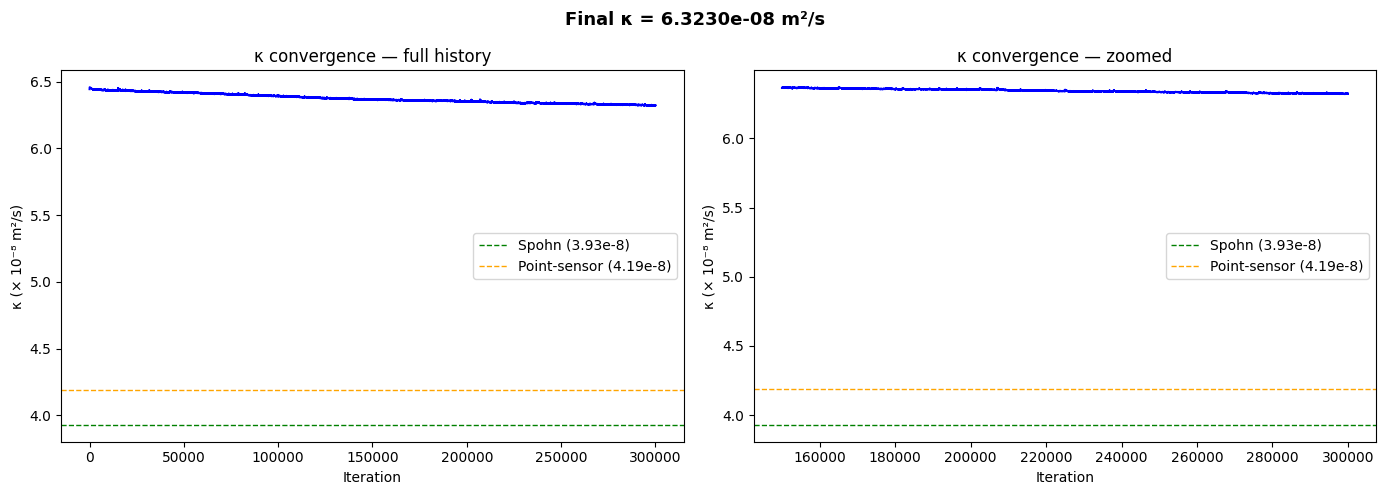

Final κ:          6.3230e-08 m²/s
Spohn reference:  3.93e-8 m²/s  (diff: +60.9%)


In [ ]:
# ── κ convergence plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = jnp.arange(1, len(kappa_history) + 1)

# (a) Full history
axes[0].plot(iters, jnp.array(kappa_history) * 1e8, 'b-', lw=1.5)
axes[0].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[0].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[0].set_title('κ convergence — full history')
axes[0].legend()

# (b) Zoomed on last 50% to see plateau
half = len(kappa_history) // 2
axes[1].plot(iters[half:], jnp.array(kappa_history)[half:] * 1e8, 'b-', lw=1.5)
axes[1].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[1].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[1].set_title('κ convergence — zoomed')
axes[1].legend()

final_kappa = kappa_history[-1]
plt.suptitle(f'Final κ = {final_kappa:.4e} m²/s', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kappa_convergence_1e-7_run02.png', dpi=150)
plt.show()

print(f"Final κ:          {final_kappa:.4e} m²/s")
print(f"Spohn reference:  3.93e-8 m²/s  (diff: {(final_kappa - 3.93e-8)/3.93e-8 * 100:+.1f}%)")

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy
import pickle

# Problem parameters
depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
z0 = 0.017
z1 = 0.363
N = 100



# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

with open('checkpoints_spatial_average/1e-7_run02.pkl', 'rb') as f:
    checkpoint = pickle.load(f)


kappa = checkpoint['final_kappa']

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# Now each data point will be calculated using the spatial average of the sensor.

# Space out the depths in N equal slices.
x_depths = jnp.linspace(z0, z1, N).reshape(-1, 1)

t_data = jnp.array(ltst_mole).reshape(-1, 1)
u_data = jnp.array(temp_mole).reshape(-1, 1)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_depths = normalize_x(x_depths)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: idctionary containging the network list of dictionaries and log_kappa
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = {}

    network = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        network.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    params['network'] = network
    params['log_kappa'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)


    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]

    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    kappa_eff = normalize_kappa(jnp.exp(params['log_kappa']))  # Ensure positivity

    return du_dt / kappa_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
params = checkpoint['params']

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={50000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, tx_all, u_data):

    def loss_fn(params):

        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel()) # (10000,) not (10000, 1)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss

        # One forward pass, reshape, average
        preds = network(params, tx_all)           # (M*100, 1)
        preds = preds.reshape(-1, N)             # (M, 100)
        avg_preds = jnp.mean(preds, axis=1, keepdims=True)  # (M, 1)
        data_loss = jnp.mean((avg_preds - u_data)**2)

        return  bc_loss * 100 + physics_loss + data_loss * 200, (bc_loss, physics_loss, data_loss)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 200000
save_every = 1000
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()


# Build (M*100, 2) tensor in one go
t_repeated = jnp.repeat(t_data, N, axis=0)      # each tᵢ repeated 100 times
x_tiled = jnp.tile(x_depths, (len(t_data), 1))  # depths tiled M times
tx_all = jnp.concatenate([t_repeated, x_tiled], axis=1)


# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
kappa_history = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        tx_all, u_data
    )

    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])
    kappa_history.append(float(jnp.exp(params['log_kappa'])))


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  BC Loss: {individual_loss[0]:.6f}, Physics Loss: {individual_loss[1]:.6f}, Data Loss: {individual_loss[2]:.6f}")
        print(f"  Current kappa: {jnp.exp(params['log_kappa']):.2e} m^2/s")



checkpoint = {
    # Learned parameters
    'params': jax.device_get(params),
    'opt_state': jax.device_get(opt_state),

    # Loss histories
    'losses': [float(l) for l in losses],
    'losses_bc': [float(l) for l in losses_bc],
    'losses_phys': [float(l) for l in losses_phys],
    'losses_data': [float(l) for l in losses_data],
    'kappa_history': kappa_history,

    # Snapshots for animation
    'snapshots': [jax.device_get(s) for s in snapshots],
    'snapshot_iterations': snapshot_iterations,

    # Training config (so you remember what produced this)
    'num_iterations': num_iterations,
    'layer_sizes': layer_sizes,
    'learning_rate': learning_rate,
    'final_kappa': float(jnp.exp(params['log_kappa'])),
}

with open('checkpoints_spatial_average/1e-7_run03.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print(f"Checkpoint saved. Final kappa: {jnp.exp(params['log_kappa']):.2e}")

/usr/local/lib/python3.12/dist-packages/openpyxl/reader/drawings.py:67: UserWarning: wmf image format is not supported so the image is being dropped
  warn(msg)


Iteration 1000/200000, Loss: 0.001362
  BC Loss: 0.000001, Physics Loss: 0.000540, Data Loss: 0.000003
  Current kappa: 6.32e-08 m^2/s
Iteration 2000/200000, Loss: 0.002251
  BC Loss: 0.000002, Physics Loss: 0.001367, Data Loss: 0.000004
  Current kappa: 6.32e-08 m^2/s
Iteration 3000/200000, Loss: 0.002338
  BC Loss: 0.000002, Physics Loss: 0.001492, Data Loss: 0.000003
  Current kappa: 6.32e-08 m^2/s
Iteration 4000/200000, Loss: 0.006367
  BC Loss: 0.000002, Physics Loss: 0.005410, Data Loss: 0.000004
  Current kappa: 6.32e-08 m^2/s
Iteration 5000/200000, Loss: 0.002838
  BC Loss: 0.000005, Physics Loss: 0.000954, Data Loss: 0.000007
  Current kappa: 6.32e-08 m^2/s
Iteration 6000/200000, Loss: 0.002013
  BC Loss: 0.000001, Physics Loss: 0.001202, Data Loss: 0.000003
  Current kappa: 6.32e-08 m^2/s
Iteration 7000/200000, Loss: 0.002155
  BC Loss: 0.000004, Physics Loss: 0.000570, Data Loss: 0.000006
  Current kappa: 6.32e-08 m^2/s
Iteration 8000/200000, Loss: 0.002655
  BC Loss: 0.0000

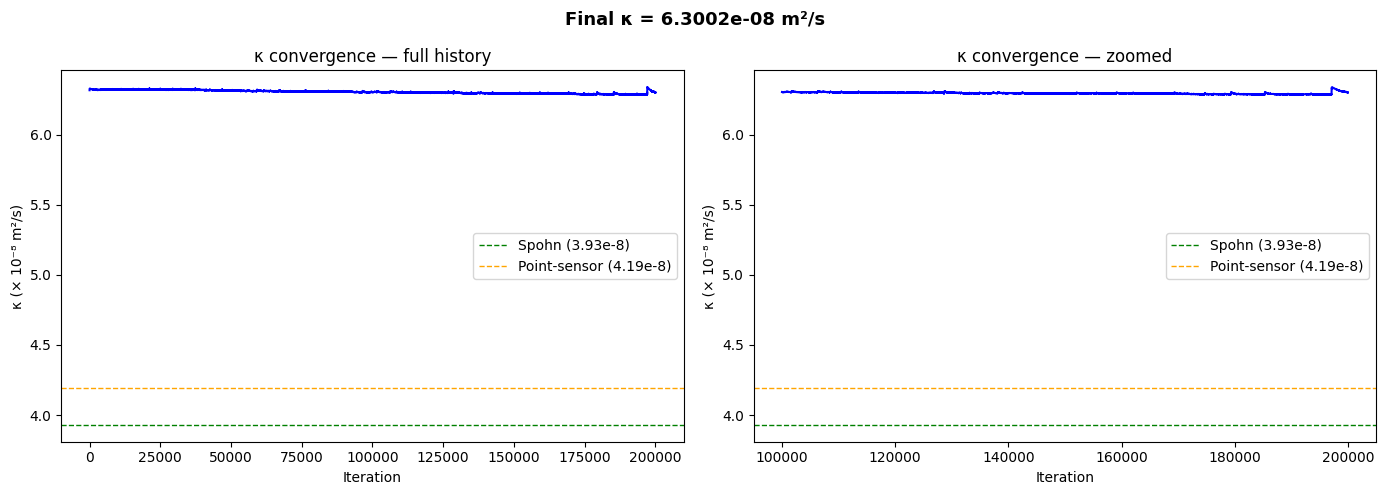

Final κ:          6.3002e-08 m²/s
Spohn reference:  3.93e-8 m²/s  (diff: +60.3%)


In [ ]:
# ── κ convergence plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = jnp.arange(1, len(kappa_history) + 1)

# (a) Full history
axes[0].plot(iters, jnp.array(kappa_history) * 1e8, 'b-', lw=1.5)
axes[0].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[0].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[0].set_title('κ convergence — full history')
axes[0].legend()

# (b) Zoomed on last 50% to see plateau
half = len(kappa_history) // 2
axes[1].plot(iters[half:], jnp.array(kappa_history)[half:] * 1e8, 'b-', lw=1.5)
axes[1].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[1].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[1].set_title('κ convergence — zoomed')
axes[1].legend()

final_kappa = kappa_history[-1]
plt.suptitle(f'Final κ = {final_kappa:.4e} m²/s', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kappa_convergence_1e-7_run03.png', dpi=150)
plt.show()

print(f"Final κ:          {final_kappa:.4e} m²/s")
print(f"Spohn reference:  3.93e-8 m²/s  (diff: {(final_kappa - 3.93e-8)/3.93e-8 * 100:+.1f}%)")

## **Check RMSE**

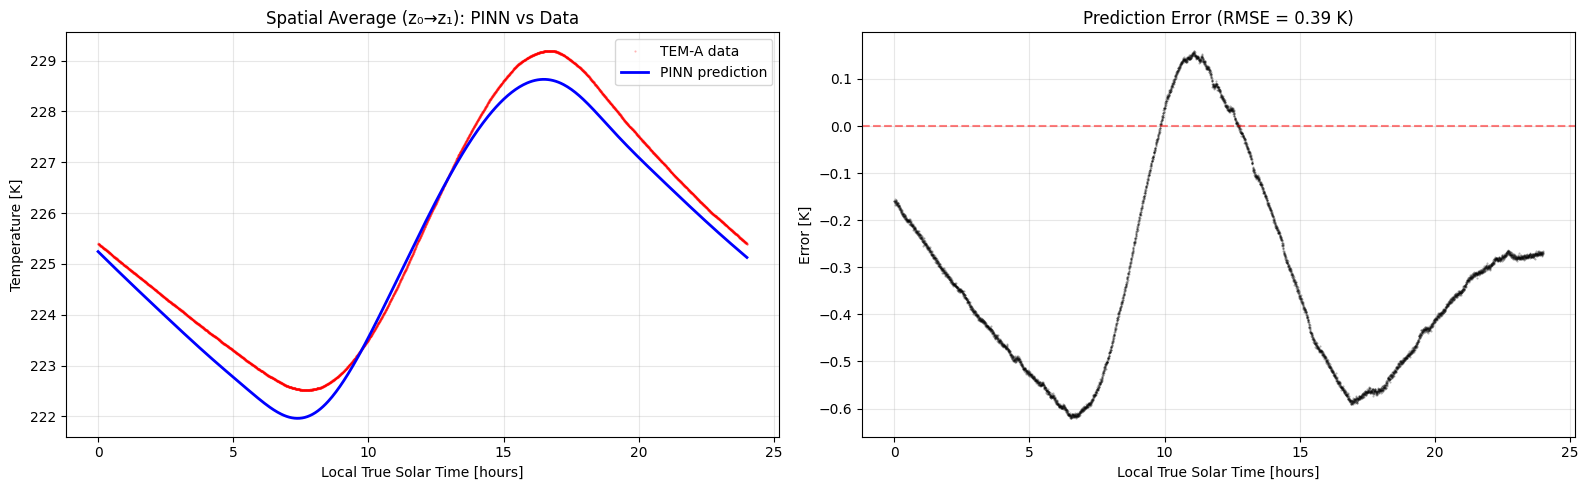

In [9]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy
import pickle

# Problem parameters
kappa = 1e-8       # thermal diffusivity [m^2/s]. We will learn this parameter.
depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
z0 = 0.017
z1 = 0.363
N = 100

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


x_depths = jnp.linspace(z0, z1, N).reshape(-1, 1)
x_depths = normalize_x(x_depths)

t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)


    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


with open('checkpoints_spatial_average/3.93e-8_run03.pkl', 'rb') as f:
    checkpoint = pickle.load(f)


kappa = checkpoint['final_kappa']
params = checkpoint['params']

# ============================================================
# Plot: Network prediction vs TEM-A data at mole depth
# ============================================================

# Create a dense time array (normalised)
t_plot = jnp.linspace(0, 1, 500).reshape(-1, 1)  # (500, 1)

# Build the same spatial average as in training
t_repeated_plot = jnp.repeat(t_plot, N, axis=0)          # (500*100, 1)
x_tiled_plot = jnp.tile(x_depths, (len(t_plot), 1))      # (500*100, 1)
tx_plot = jnp.concatenate([t_repeated_plot, x_tiled_plot], axis=1)  # (500*100, 2)

# Forward pass, reshape, average over depths
u_pred_norm = network(params, tx_plot)        # (50000, 1)
u_pred_norm = u_pred_norm.reshape(-1, N)      # (500, 100)
u_pred_avg = jnp.mean(u_pred_norm, axis=1)   # (500,)

# Convert back to physical units
t_plot_hours = np.array(t_plot.ravel()) * 24
u_pred_K = np.array(unnormalize_u(u_pred_avg))

# Also convert mole data back to hours for comparison
t_mole_hours = np.array(ltst_mole) * 24 / sol_seconds * (24/24)
# Actually ltst_mole is already in seconds (converted earlier), so:
t_mole_hours = np.array(ltst_mole) / sol_seconds * 24  # seconds -> LTST hours
u_mole_K = np.array(temp_mole)  # already in Kelvin

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: overlay prediction and data
ax1 = axes[0]
ax1.plot(t_mole_hours, u_mole_K, 'r.', markersize=1, alpha=0.3, label='TEM-A data')
ax1.plot(t_plot_hours, u_pred_K, 'b-', linewidth=2, label='PINN prediction')
ax1.set_xlabel('Local True Solar Time [hours]')
ax1.set_ylabel('Temperature [K]')
ax1.set_title('Spatial Average (z₀→z₁): PINN vs Data')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: error (prediction - data) over time
# Interpolate prediction to data time points for direct comparison
u_pred_at_data = np.interp(t_mole_hours, t_plot_hours, u_pred_K)
error = u_pred_at_data - u_mole_K

ax2 = axes[1]
ax2.plot(t_mole_hours, error, 'k.', markersize=1, alpha=0.3)
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax2.set_xlabel('Local True Solar Time [hours]')
ax2.set_ylabel('Error [K]')
ax2.set_title(f'Prediction Error (RMSE = {np.sqrt(np.mean(error**2)):.2f} K)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()